## Part 1: Lab Setup
1.1 Install Required Libraries

In [4]:
!pip uninstall torch torchvision torchaudio numpy -y
!pip install tensorflow matplotlib seaborn
!pip install numpy

Found existing installation: torch 2.13.0
Uninstalling torch-2.13.0:
  Successfully uninstalled torch-2.13.0
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/opt_einsum-3.4.0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/dill-0.3.9-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/lightning_utilities-0.12.0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg a

## 1.2 Import Packages

In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

Part 2: Load and Explore Dataset

In [8]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize data
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape for CNN: (28, 28) -> (28, 28, 1)
x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step 
Training data shape: (60000, 28, 28, 1)
Testing data shape: (10000, 28, 28, 1)


## Show Sample Images

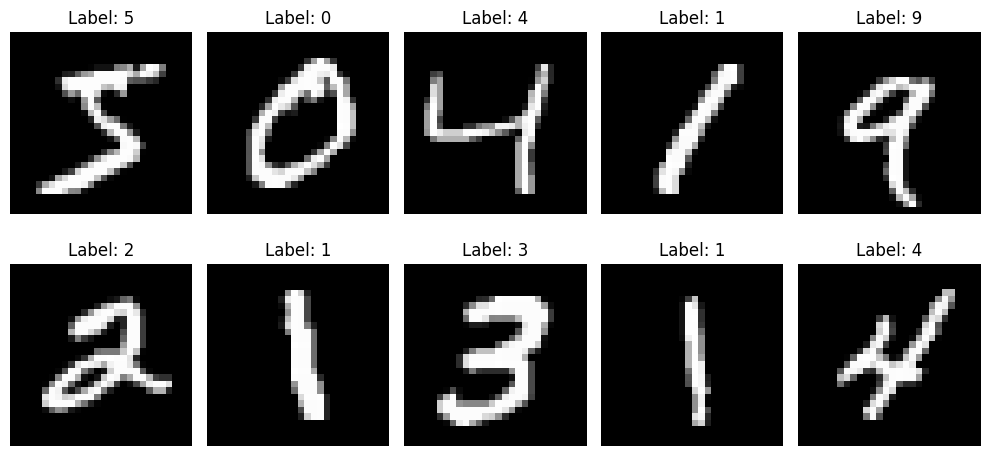

In [9]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Part 3: Build CNN Model
3.1 Simple CNN Architecture

In [10]:
model = models.Sequential([
    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        input_shape=(28, 28, 1),
        name="conv2d_1"
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64,
        (3, 3),
        activation="relu",
        name="conv2d_2"
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
W0000 00:00:1786981340.321356    4183 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1786981340.325935    4183 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1786981340.538004    4183 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5233 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5060 Lap

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

## 3.2 Compile Model

In [11]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## Part 4: Train the Model

In [12]:
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    validation_data=(x_test, y_test),
    batch_size=128
)

Epoch 1/5


I0000 00:00:1786981354.613783    4693 service.cc:153] XLA service 0x732ad80321a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1786981354.613844    4693 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5060 Laptop GPU, Compute Capability 12.0a (Driver: 13.3.0; Runtime: 12.6.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1786981354.646646    4693 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1786981354.833136    4693 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1786981354.862822    4693 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1668__.31
I0000 00:00:1786981356.658226    4766 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_8', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1786981356.729508    4762 subprocess_compilation.cc:348] p

  9/469 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.2622 - loss: 2.1767   

I0000 00:00:1786981361.230780    4693 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


461/469 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9142 - loss: 0.2790 

I0000 00:00:1786981363.417740    4696 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1668__.31
I0000 00:00:1786981363.900426    4971 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_8', 16 bytes spill stores, 16 bytes spill loads

I0000 00:00:1786981363.955956    4972 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_8', 28 bytes spill stores, 24 bytes spill loads

I0000 00:00:1786981364.351333    4976 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_14', 8 bytes spill stores, 8 bytes spill loads



469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 22ms/step - accuracy: 0.9151 - loss: 0.2762 - val_accuracy: 0.9784 - val_loss: 0.0674
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9736 - loss: 0.0868 - val_accuracy: 0.9860 - val_loss: 0.0447
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9787 - loss: 0.0673 - val_accuracy: 0.9883 - val_loss: 0.0372
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9827 - loss: 0.0551 - val_accuracy: 0.9896 - val_loss: 0.0330
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9850 - loss: 0.0470 - val_accuracy: 0.9906 - val_loss: 0.0290


## Part 5: Evaluate Model

In [13]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc * 100:.2f}%")

313/313 - 2s - 6ms/step - accuracy: 0.9906 - loss: 0.0290
Test Loss: 0.0290
Test Accuracy: 99.06%


## Plot Learning Curves

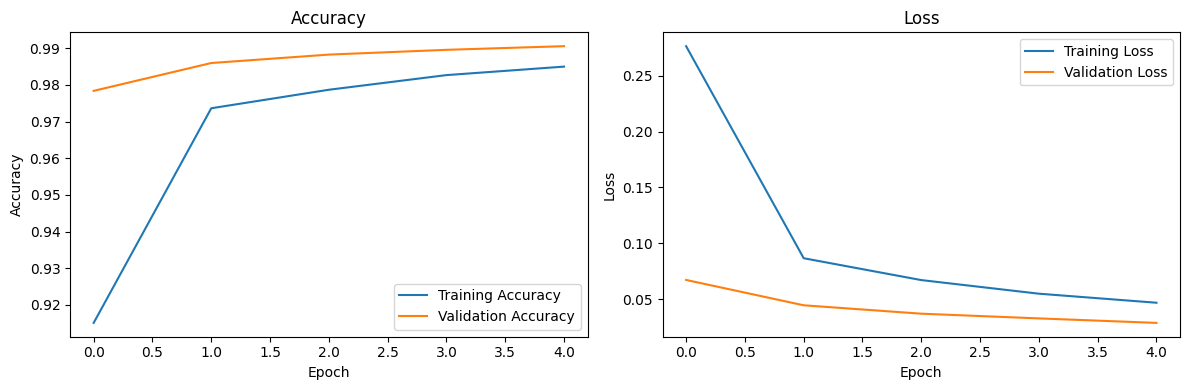

In [14]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()


## Confusion Matrix

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step    


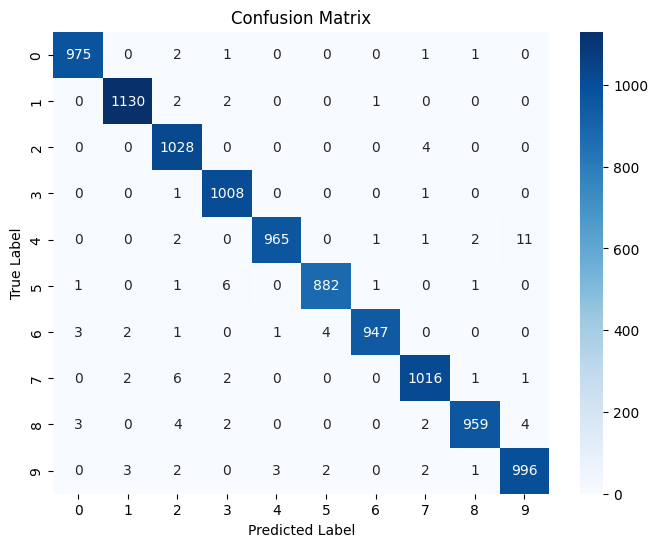

In [15]:
y_pred_prob = model.predict(x_test)
y_pred = np.argmax(y_pred_prob, axis=1)

cm = tf.math.confusion_matrix(y_test, y_pred).numpy()

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## Part 6: Visualize Filters

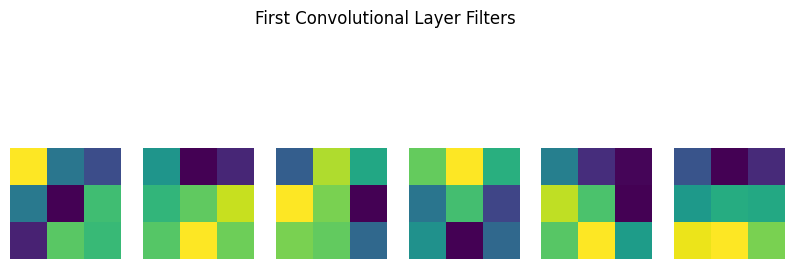

In [16]:
# Extract weights of the first Conv2D layer
filters, biases = model.get_layer("conv2d_1").get_weights()

# Normalize filter values for visualization
filters = filters - filters.min()
filters = filters / filters.max()

plt.figure(figsize=(10, 4))

for i in range(6):
    plt.subplot(1, 6, i + 1)
    plt.imshow(filters[:, :, 0, i], cmap="viridis")
    plt.axis("off")

plt.suptitle("First Convolutional Layer Filters")
plt.show()

In [ ]:
## Part 7: Visualize Grad-CAM
7.1 Define Grad-CAM Function

In [17]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    denominator = tf.math.reduce_max(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (denominator + 1e-8)

    return heatmap.numpy()

## 7.2 Apply Grad-CAM

In [18]:
img_index = 1
img = x_test[img_index][np.newaxis, ...]

heatmap = make_gradcam_heatmap(
    img_array=img,
    model=model,
    last_conv_layer_name="conv2d_2"
)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(x_test[img_index].squeeze(), cmap="gray")
plt.title(f"Original Image: Label {y_test[img_index]}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.matshow(heatmap, fignum=False, cmap="jet")
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.tight_layout()
plt.show()

AttributeError: The layer sequential has never been called and thus has no defined output.

## Part 8: Prediction Inspection
Inspect several predictions visually to identify correct and incorrect classifications.

In [ ]:
sample_indices = np.arange(10)
sample_images = x_test[sample_indices]
sample_labels = y_test[sample_indices]

sample_probs = model.predict(sample_images)
sample_preds = np.argmax(sample_probs, axis=1)

plt.figure(figsize=(12, 5))

for i, idx in enumerate(sample_indices):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[idx].squeeze(), cmap="gray")
    plt.title(f"True: {sample_labels[i]} | Pred: {sample_preds[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Part 9: Optional Experiments

In [ ]:
# Example experiment ideas:
# 1. Change activation='relu' to activation='tanh'
# 2. Change optimizer='adam' to optimizer='sgd' or optimizer='rmsprop'
# 3. Add BatchNormalization after Conv2D layers
# 4. Change Dropout from 0.5 to 0.25
# 5. Increase epochs from 5 to 10
# 6. Add EarlyStopping callback

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

In [ ]:
## Part 10: Save the Mode

In [ ]:
model.save("lecture6_lab2_cnn_mnist_model.keras")

print("Model saved as lecture6_lab2_cnn_mnist_model.keras")